In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [24]:
print(os.getcwd())

/Users/eugenechua/Downloads/marketing_datasets_EDA


Let us start by reading in the dataset.

In [25]:
# Reading in the data
email_marketing_df = pd.read_csv('kevin_hillstrom_data.csv')
email_marketing_df.head(10)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
6,9,3) $200 - $350,280.20,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
7,9,1) $0 - $100,46.42,0,1,Urban,0,Phone,Womens E-Mail,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0
9,10,1) $0 - $100,32.84,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


In [26]:
print(email_marketing_df.shape)
print(email_marketing_df.isnull().sum())

(64000, 12)
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64


HAHAHAHA no missing values oopsie! - 64,000 records

**About the dataset:** Kevin Hillstrom's email test. 64,000 customers were randomly split into Men's Email, Women's Email, or no email (control), then tracked for two weeks.

**Fields:**
- `recency`: months since last purchase
- `history` / `history_segment`: past-year spend ($ / banded)
- `mens`, `womens`: bought that category in the past year
- `zip_code`: Urban, Suburban or Rural
- `newbie`: new customer in past 12 months
- `channel`: channel of past-year purchases (Phone, Web, Multichannel)
- `segment`: email group received
- `visit`, `conversion`: visited site / purchased within 2 weeks
- `spend`: $ spent within 2 weeks

            count   pct
conversion             
0           63422  99.1
1             578   0.9


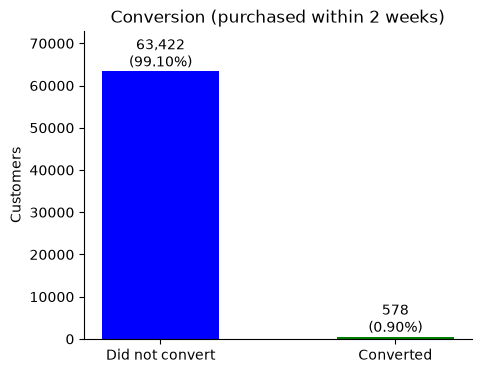

In [27]:
# How many converted?
conv_counts = email_marketing_df['conversion'].value_counts().sort_index()
conv_pct = email_marketing_df['conversion'].value_counts(normalize=True).sort_index() * 100
print(pd.DataFrame({'count': conv_counts, 'pct': conv_pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Did not convert', 'Converted'], conv_counts.values, color=['blue', 'green'], width=0.5)
for b, c, p in zip(bars, conv_counts.values, conv_pct.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{c:,}\n({p:.2f}%)', ha='center', va='bottom')
ax.set_ylabel('Customers')
ax.set_title('Conversion (purchased within 2 weeks)')
ax.set_ylim(0, conv_counts.max() * 1.15)
sns.despine()
plt.show()

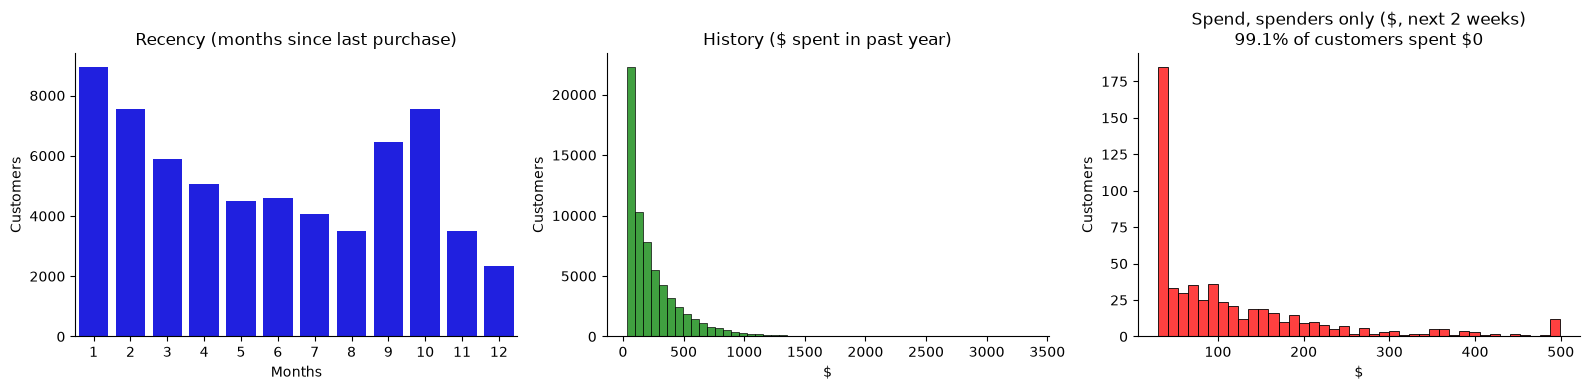

        recency   history     spend
count  64000.00  64000.00  64000.00
mean       5.76    242.09      1.05
std        3.51    256.16     15.04
min        1.00     29.99      0.00
25%        2.00     64.66      0.00
50%        6.00    158.11      0.00
75%        9.00    325.66      0.00
max       12.00   3345.93    499.00

Spend among spenders:
count    578.00
mean     116.36
std      107.87
min       29.99
25%       32.27
50%       80.80
75%      153.35
max      499.00
Name: spend, dtype: float64


In [28]:
# Distributions: recency, history, spend
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x='recency', data=email_marketing_df, color='blue', ax=axes[0])
axes[0].set_title('Recency (months since last purchase)')
axes[0].set_xlabel('Months'); axes[0].set_ylabel('Customers')

sns.histplot(email_marketing_df['history'], bins=50, color='green', ax=axes[1])
axes[1].set_title('History ($ spent in past year)')
axes[1].set_xlabel('$'); axes[1].set_ylabel('Customers')

# Spend is ~99% zeros, so show spenders only and note the zero share
spenders = email_marketing_df.loc[email_marketing_df['spend'] > 0, 'spend']
sns.histplot(spenders, bins=40, color='red', ax=axes[2])
zero_pct = (email_marketing_df['spend'] == 0).mean() * 100
axes[2].set_title(f'Spend, spenders only ($, next 2 weeks)\n{zero_pct:.1f}% of customers spent $0')
axes[2].set_xlabel('$'); axes[2].set_ylabel('Customers')

sns.despine()
plt.tight_layout()
plt.show()

print(email_marketing_df[['recency', 'history', 'spend']].describe().round(2))
print('\nSpend among spenders:'); print(spenders.describe().round(2))

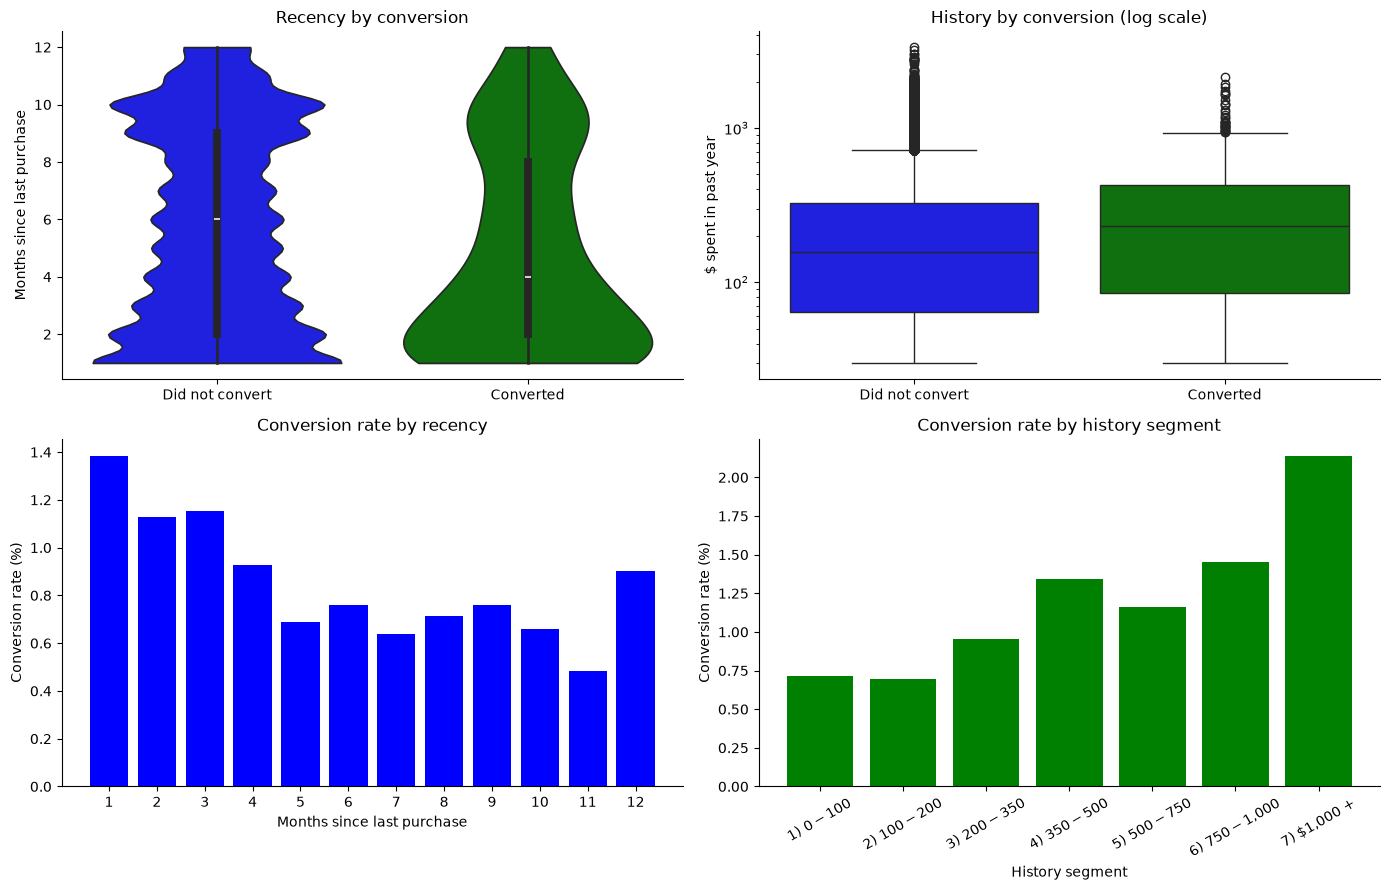

In [29]:
# Recency and history vs conversion
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_df = email_marketing_df.assign(converted=email_marketing_df['conversion'].map({0: 'Did not convert', 1: 'Converted'}))
order = ['Did not convert', 'Converted']

# Top row: distributions by outcome
sns.violinplot(x='converted', y='recency', data=plot_df, order=order, hue='converted', palette=['blue', 'green'], legend=False, cut=0, ax=axes[0, 0])
axes[0, 0].set_title('Recency by conversion'); axes[0, 0].set_xlabel(''); axes[0, 0].set_ylabel('Months since last purchase')

sns.boxplot(x='converted', y='history', data=plot_df, order=order, hue='converted', palette=['blue', 'green'], legend=False, ax=axes[0, 1])
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('History by conversion (log scale)'); axes[0, 1].set_xlabel(''); axes[0, 1].set_ylabel('$ spent in past year')

# Bottom row: conversion rate per group (easier to read when conversions are rare)
rate_recency = email_marketing_df.groupby('recency')['conversion'].mean() * 100
axes[1, 0].bar(rate_recency.index.astype(str), rate_recency.values, color='blue')
axes[1, 0].set_title('Conversion rate by recency'); axes[1, 0].set_xlabel('Months since last purchase'); axes[1, 0].set_ylabel('Conversion rate (%)')

rate_hist = email_marketing_df.groupby('history_segment')['conversion'].mean() * 100
axes[1, 1].bar(rate_hist.index, rate_hist.values, color='green')
axes[1, 1].set_title('Conversion rate by history segment'); axes[1, 1].set_xlabel('History segment'); axes[1, 1].set_ylabel('Conversion rate (%)')
axes[1, 1].tick_params(axis='x', rotation=30)

sns.despine()
plt.tight_layout()
plt.show()

We can see that on average, those who converted are more **recent** (just a couple of months since last purchase). This is confirmed by both the violinplot and barplot. We can also see that historical spends on average is higher for those who converted.

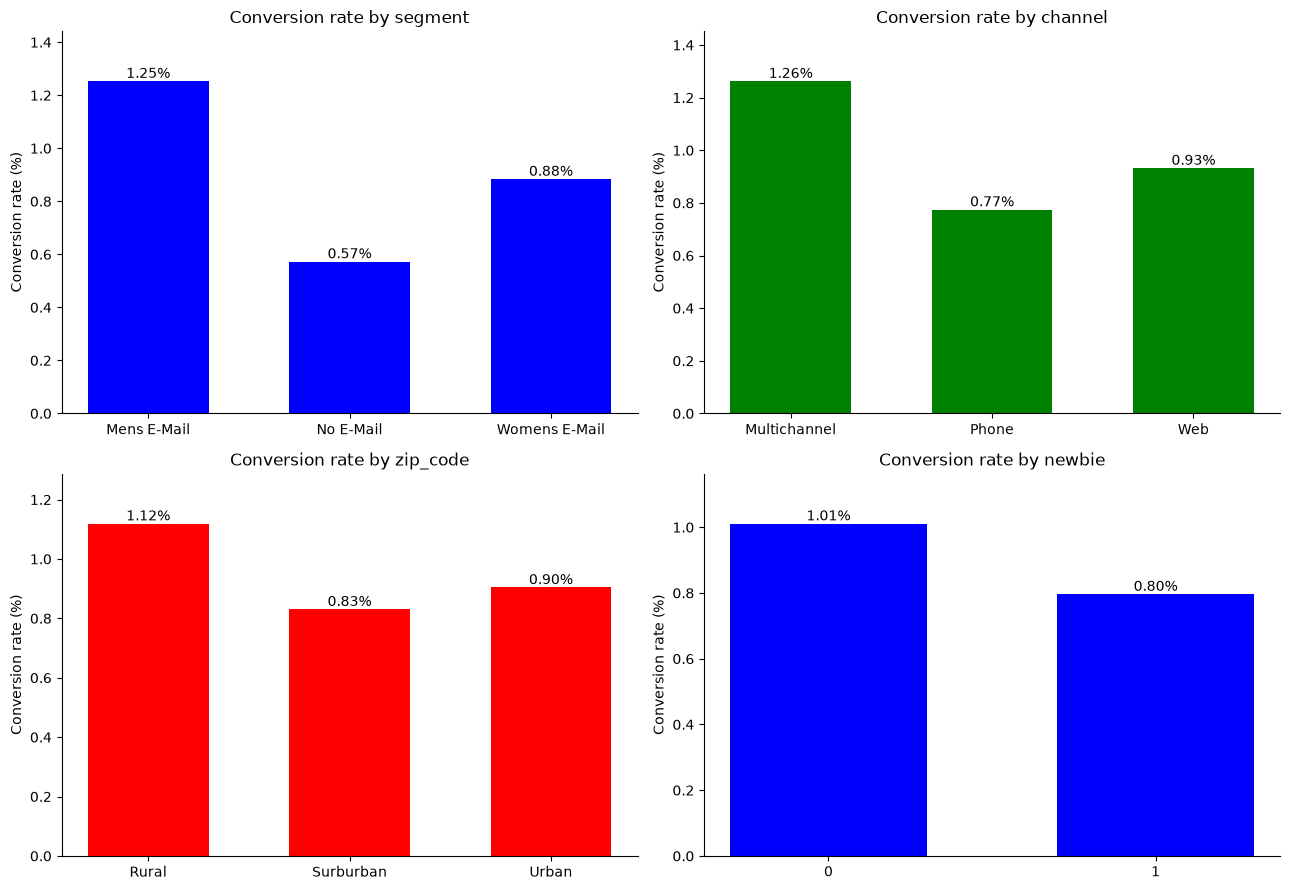

In [30]:
# Conversion rate by segment, channel, zip_code and newbie
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col, color in zip(axes.flat, ['segment', 'channel', 'zip_code', 'newbie'], ['blue', 'green', 'red', 'blue']):
    rate = email_marketing_df.groupby(col)['conversion'].mean() * 100
    ax.bar(rate.index.astype(str), rate.values, color=color, width=0.6)
    for i, v in enumerate(rate.values):
        ax.text(i, v, f'{v:.2f}%', ha='center', va='bottom')
    ax.set_title(f'Conversion rate by {col}'); ax.set_xlabel(''); ax.set_ylabel('Conversion rate (%)')
    ax.set_ylim(0, rate.max() * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

Alright, looking at conversion rates now...we can see that conversion rates is highest among `Mens E Email`, `Multichannel`, `Rural`, and non `Newbie`.

578 converters
count    578.00
mean     116.36
std      107.87
min       29.99
25%       32.27
50%       80.80
75%      153.35
max      499.00
Name: spend, dtype: float64


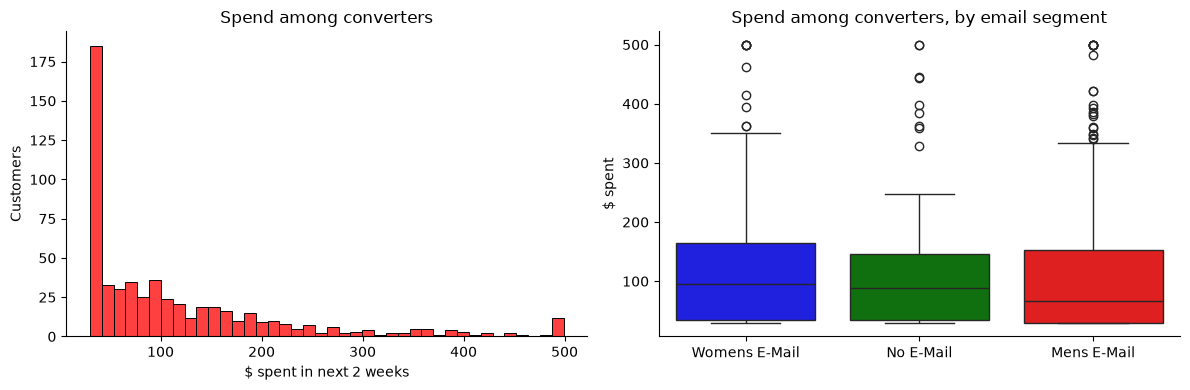

In [31]:
# Spend distribution among converters only
converters = email_marketing_df[email_marketing_df['conversion'] == 1]
print(f'{len(converters):,} converters')
print(converters['spend'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(converters['spend'], bins=40, color='red', ax=axes[0])
axes[0].set_title('Spend among converters'); axes[0].set_xlabel('$ spent in next 2 weeks'); axes[0].set_ylabel('Customers')

sns.boxplot(x='segment', y='spend', data=converters, hue='segment', palette=['blue', 'green', 'red'], legend=False, ax=axes[1])
axes[1].set_title('Spend among converters, by email segment'); axes[1].set_xlabel(''); axes[1].set_ylabel('$ spent')

sns.despine()
plt.tight_layout()
plt.show()

Spend among converters is right-skewed (median ~$81, mean $116), with a spike near $30 and a small bump at $500. Median spend differs by segment (Womens ~$95, No E-Mail ~$88, Mens ~$67), but means are close ($114-$122) and the boxes overlap heavily, so this may be noise.

In [33]:
email_marketing_df.head(5)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [35]:
email_marketing_df.head(10)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
6,9,3) $200 - $350,280.20,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
7,9,1) $0 - $100,46.42,0,1,Urban,0,Phone,Womens E-Mail,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0
9,10,1) $0 - $100,32.84,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


In [38]:
# Feature prep for a basic propensity model (logistic regression)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

model_df = email_marketing_df.copy()
model_df['zip_code'] = model_df['zip_code'].replace({'Surburban': 'Suburban'})  # fix typo on the copy only
model_df['log_history'] = np.log1p(model_df['history'])  # history is right-skewed

# history_segment dropped (banded duplicate of history); visit and spend dropped (post-email outcomes)
features = ['recency', 'log_history', 'mens', 'womens', 'newbie', 'zip_code', 'channel', 'segment']
X = pd.get_dummies(model_df[features], columns=['zip_code', 'channel', 'segment'], drop_first=True, dtype=int)
y = model_df['conversion']

# Stratify because only ~1% convert
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale only the continuous columns, fitting on train to avoid leakage into test
num_cols = ['recency', 'log_history']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(X_train.shape, X_test.shape)
print(f'Conversion rate - train: {y_train.mean():.4f}, test: {y_test.mean():.4f}')
print(list(X_train.columns))

(51200, 11) (12800, 11)
Conversion rate - train: 0.0090, test: 0.0091
['recency', 'log_history', 'mens', 'womens', 'newbie', 'zip_code_Suburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web', 'segment_No E-Mail', 'segment_Womens E-Mail']


In [39]:
X_train.head(10)

,recency,log_history,mens,womens,newbie,zip_code_Suburban,zip_code_Urban,channel_Phone,channel_Web,segment_No E-Mail,segment_Womens E-Mail
63250,1.490220,-1.540341,1,0,1,1,0,0,1,0,1
22437,-0.218999,0.032981,1,0,0,0,1,0,1,0,1
503,0.065871,1.241194,1,1,1,0,1,0,0,0,1
10648,-0.218999,-0.911636,1,0,0,0,0,1,0,0,1
48649,-0.788739,-1.036348,0,1,1,0,1,1,0,0,0
39289,-1.358479,1.314644,0,1,1,0,1,1,0,1,0
22408,0.920480,-1.540341,0,1,0,0,1,1,0,0,1
54764,-1.073609,-1.164714,0,1,0,0,1,1,0,0,1
56324,1.205350,-0.059037,0,1,1,0,0,1,0,1,0
51487,-0.503869,0.182253,0,1,1,0,1,1,0,0,1


## Propensity modeling vs. uplift modeling

**Propensity modeling** asks: *how likely is this customer to buy?* We train a model on customer features (recency, past spend, etc.) to predict P(convert), then target the highest scores. The catch: a high score only tells us the customer is a keen buyer, not that our email made them buy. Many would have purchased with no email at all.

**Uplift modeling** asks: *how much does the email change this customer's chance of buying?*

uplift = P(convert if emailed) − P(convert if not emailed)

We can never see both outcomes for one person, so we rely on the randomised test: customers were randomly split into Men's Email, Women's Email and no email. Randomisation makes the groups comparable, so differences in conversion can be credited to the email.

**ATE vs. CATE**
- **ATE** (average treatment effect): the email's average effect across *all* customers. One number.
- **CATE** (conditional average treatment effect): the effect for a *type* of customer, e.g. long-lapsed buyers vs. recent buyers. Uplift modeling estimates this.

**Why it matters to the business**
Emails cost money, and some customers dislike them. Customers fall into four groups:
- **Persuadables:** buy only if emailed → target
- **Sure things:** buy anyway → emailing wastes money
- **Lost causes:** won't buy either way → skip
- **Sleeping dogs:** the email lowers their chance of buying → avoid

Propensity models tend to chase sure things. Uplift models look for persuadables, so the same budget produces more *extra* sales.

**Next step:** an S-learner (one model with treatment as a feature) and a T-learner (one model per group), compared using uplift/Qini curves.